## Introduction

In this project, we will be using several Python libraries to make a K-Nearest Neighbor classifier that will be trained to predeict whether or not a patient has breast cancer.

The dataset that will be used will be the `load_breast_cancer` dataset from the `sklearn` Python library.

## Preparation

Before beginning the main protion of the project, we will need to install and import the necessary packages and modules into our Python virtual environment.

In [ ]:
# Installing necessary packages and modules
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

In [2]:
# Importing the necessary packages and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline

Now that we have imported all of the necessary packages and modules, the last thing that we need to do before beginning our analysis is load in our dataset, which we have already imported into the environment as it is included in the Python library, `sklearn`.

In [3]:
# Loading the breast cancer dataset from sklearn
breast_cancer_data = load_breast_cancer()

Before we can jump right into our K-Nearest Neighbor classifier, we should look at our dataset just to get a little bit more of an idea of what we are dealing with.

To do this, we will print the first datapoint in our dataset, as well as printing the feature names of our data.

In [4]:
# Printing first datapoint
print(breast_cancer_data.data[0])

# Printing feature names
print(breast_cancer_data.feature_names)

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


With the output above, we can now see all of the features that we are dealing with in our dataset, as well as all of the measures of these features from the first registered datapoint.

Now that we at least have a sense of what our data looks like, we want to start to identify exactly what it is we are trying to classify within our model.

To do this, we will print `breast_cancer_data.target` and `breast_cancer_data.target_names`.

This will give us the labels of every data point (`.target`).
This will give us the label of what corresponds to a benign or malignant tumor (`.target_names`).


In [5]:
# Printing target
print(breast_cancer_data.target)

# Printing target_names
print(breast_cancer_data.target_names)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

From the output above, we can see that a value of `0` corresponds to `malignant` while a value of `1` corresponds to `benign`.

We can also see that the very first datapoint has a value of `0`, meaning that this tumor is `malignant`.

Now that we have our data, the next thing that we need to do is split it into training and validation sets.

We can do this rather easily using the `train_test_split` function from `sklearn.model_selection`.

When we call the `train_test_split` function, it takes a variety of parameters:

- The data that we want to split (`breast_cancer_data.data`)
- The labels associated with that data (`breast_cancer_data.target`)
- The `test_size`, which is the percentage of our dataset that we want to be in our validation set (`test_size = 0.2`)
- The `random_state`, which will ensure that everytime our code is run, the data will be split in the same way (`random_state = 100`)

Now, let's split our data.

In [6]:
# Splitting our data into training and validation sets
training_data, validation_data, training_labels, validation_labels = train_test_split(
    breast_cancer_data.data, breast_cancer_data.target, test_size=0.2, random_state=100
)

To confirm that this split worked correctly, we will print out the length of `training_data` and `training_labels`.

Ideally, these two lengths should be the same to ensure that we have one label for every piece of data.

In [7]:
# Printing lengths
print(len(training_data))
print(len(training_labels))

455
455


As we can see above, we have a perfect split of our data.

Now that we have created our training and validation sets, we are ready to create a `KNeighborsClassifier` and test its accuracy.

Note that we have already imported `KNeighborsClassifier` from `sklearn.neighbors`.

We will now create a `KNeighborsClassifier`, `classifier`, where the `n_neighbors` (number of neighbors) is equal to 3.

In [8]:
# Creating KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=3)

Now that we have our classifier defined, we can now train the classifier using the `fit` function.

When we fit the classifier, this function will take two arguments:
- The training set (`training_data`)
- The training labels (`training_labels`)

In [9]:
# Fitting our classifier
classifier.fit(training_data, training_labels)

KNeighborsClassifier(n_neighbors=3)

Now that we have our trained classifer, we can use the `score` function to see how accurate it is when tested on our validation set.

The score function takes two arguments here:
- The validation set (`validation_data`)
- The validation labels (`validation_labels`)

In [ ]:
# Printing classifier score
print(classifier.score(validation_data, validation_labels))

We can see that our classifier is being scored at a level 94.7% accuracy.

With a 94.7% accuracy score, we can see that our classifier performs rather well when `n_neighbors` or `k` is set equal to 3.

However, one thing that we should investigate is whether or not there is a better `k` value that will result in a higher accuracy score within our classifier.

To investigate this, we will essentially be placing the last three lines of code (creating, training, and reporting the accuracy of our classifier) inside of a for loop.

The loop will contain a variable, `k`, that will start at a value of 1, and will increase to a value of 100.
When doing this, we will be able to test the accuracy of our model when `k` is any value between 1 and 100.

In [11]:
# Creating a list to store different classifier scores
accuracies = []

# Creating for loop
for k in range(1, 101):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(training_data, training_labels)
    accuracies.append(classifier.score(validation_data, validation_labels))

Now that we have our list of accuracy scores for 100 values of `k`, the next thing that we should begin to do is plot our results on a graph, rather than just simply displaying them in a list.

The x-axis will be the values of `k` that were tested. Therefore, this will be a list of the numbers between 1 and 100. 

The y-axis will be the values of our accuracy scores stored in list `accuracies`.

In [12]:
# Creating list of values for x-axis
k_list = list(range(1, 101))

The last thing that we need to do is plot out data!

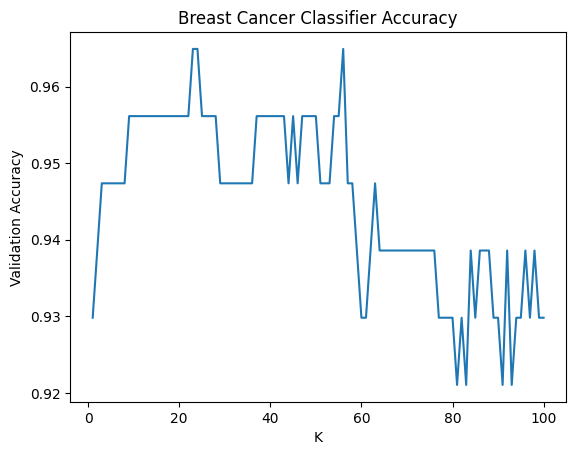

In [13]:
# Plotting data
plt.plot(k_list, accuracies)
plt.xlabel("K")
plt.ylabel("Validation Accuracy")
plt.title("Breast Cancer Classifier Accuracy")
plt.show()